 # Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_top.png" align="left" width="500">

## Setup

Load and/or check for needed environmental variables

In [3]:
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env(".env")  # check environmental variables
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)  # check packages

OPENAI_API_KEY=****ywsA
DEEPSEEK_API_KEY=****c1e4
DEEPSEEK_BASE_URL=****.com
LANGSMITH_API_KEY=****b63c
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=****ials
Python 3.11.14 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status | path                                           
---------------------- | -------- | --------- | ------ | -----------------------------------------------
langgraph              | >=1.0.0  | 1.0.5     | ✅ OK   | D:\Anaconda\envs\ai_study-311\Lib\site-packages
langchain              | >=1.0.0  | 1.2.0     | ✅ OK   | D:\Anaconda\envs\ai_study-311\Lib\site-packages
langchain-core         | >=1.0.0  | 1.2.7     | ✅ OK   | D:\Anaconda\envs\ai_study-311\Lib\site-packages
langchain-openai       | >=1.0.0  | 1.1.6     | ✅ OK   | D:\Anaconda\envs\ai_study-311\Lib\site-packages
langchain-anthropic    | >=1.0.0  | 1.3.1     | ✅ OK   | D:\Anaconda\envs\ai_study-311\Lib\site-packages
langchain-community    | >=0.4    | 0.4.1     | ✅ OK   |

In [4]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

Define the runtime context to provide the agent and tools with access to the database.

In [5]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [6]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime


@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [7]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
- 最后最重要的一点是请使用中文回答。
- must response with Chinese
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list.

In [9]:
from langchain.agents import create_agent

agent = create_agent(
    model="deepseek-chat",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Here's a display of the agent ReAct Loop.

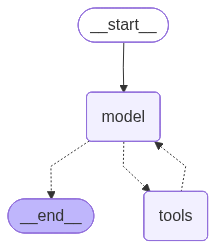

In [10]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [43]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
        {"messages": question},
        context=RuntimeContext(db=db),
        stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?
================================== Ai Message ==================================

我来帮您找出哪个表拥有最多的条目。首先，我需要查看数据库中有哪些表。
Tool Calls:
  execute_sql (call_00_rqsJdeJAgOBdQexf0YTJ6AFs)
 Call ID: call_00_rqsJdeJAgOBdQexf0YTJ6AFs
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

现在我知道了数据库中有11个表。接下来，我需要逐个查询每个表的记录数量，以找出哪个表拥有最多的条目。
Tool Calls:
  execute_sql (call_00_U4u3kmnSv2cNvHzVcwaZr9K5)
 Call ID: call_00_U4u3kmnSv2cNvHzVcwaZr9K5
  Args:
    query: SELECT 'Album' as table_name, COUNT(*) as row_co

In [44]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
        {"messages": question},
        context=RuntimeContext(db=db),
        stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================

我来帮您分析哪个流派的曲目平均时长最长。首先，我需要查看数据库的结构，了解有哪些表以及它们之间的关系。
Tool Calls:
  execute_sql (call_00_TaCEQTJdp2pBm8KXmx4TfoFG)
 Call ID: call_00_TaCEQTJdp2pBm8KXmx4TfoFG
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

现在让我查看与流派（Genre）和曲目（Track）相关的表结构：
Tool Calls:
  execute_sql (call_00_oeJVmPUZZOhNtzNqhByO4608)
 Call ID: call_00_oeJVmPUZZOhNtzNqhByO4608
  Args:
    query: PRAGMA table_info(Genre);
=====================

In [45]:
question = "Please list all of the tables"

for step in agent.stream(
        {"messages": question},
        context={"db": db},
        stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================

我来查看数据库中的所有表。
Tool Calls:
  execute_sql (call_00_TQfVCxnayD3IjSdi26Hjvpd2)
 Call ID: call_00_TQfVCxnayD3IjSdi26Hjvpd2
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

数据库中共有11个表：

1. **Album** - 专辑表
2. **Artist** - 艺术家表  
3. **Customer** - 客户表
4. **Employee** - 员工表
5. **Genre** - 流派表
6. **Invoice** - 发票表
7. **InvoiceLine** - 发票明细表
8. **MediaType** - 媒体类型表
9. **Playlist** - 播放列表表
10. **PlaylistTrack** - 播放列表曲目关联表
11. **Trac

**Create your own query here!**  Add some questions of your own.

In [ ]:
question = "TRY YOUR OWN QUERY HERE"

for step in agent.stream(
        {"messages": question},
        context={"db": db},
        stream_mode="values",
):
    step["messages"][-1].pretty_print()

### Let's try this Studio